## Calibration Plot

In [13]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
X, y = make_classification(
    n_samples=10000,
    n_features=20,
    n_informative=5,
    n_redundant=8,
    n_repeated=0,
    n_clusters_per_class=2,
    class_sep=0.8,
    flip_y=0.15,          # introduce label noise
    random_state=42
)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,stratify=y,random_state=42)

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

est_lr=LogisticRegression().fit(X_train,y_train)
est_nb=GaussianNB().fit(X_train,y_train)

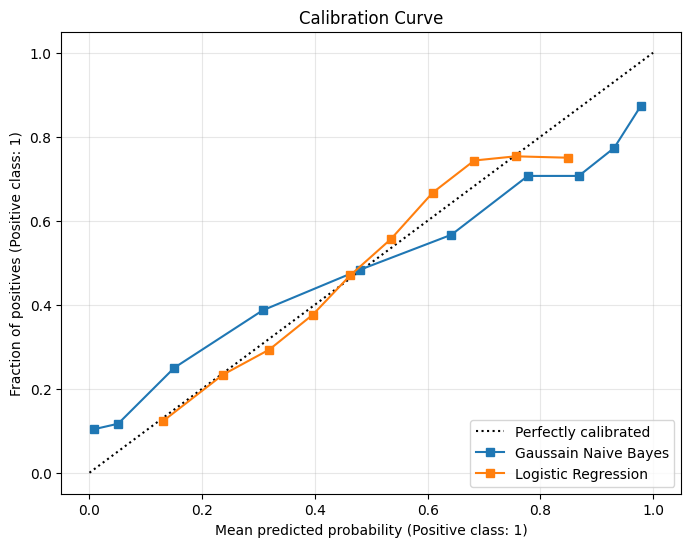

In [15]:
## Plot Calibration curves
import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay
fig,axes=plt.subplots(figsize=(8,6))

CalibrationDisplay.from_estimator(
    est_nb,
    X_test,
    y_test,
    n_bins=10,
    strategy='quantile',
    name='Gaussain Naive Bayes',
    ax=axes
)

CalibrationDisplay.from_estimator(
    est_lr,
    X_test,
    y_test,
    n_bins=10,
    strategy='quantile',
    name='Logistic Regression',
    ax=axes
)

axes.set_title("Calibration Curve")
axes.grid(alpha=0.3)

## Compare Brier Score

In [18]:
from sklearn.metrics import brier_score_loss

lr_prob=est_lr.predict_proba(X_test)[:,1]
nb_prob=est_nb.predict_proba(X_test)[:,1]

print(f"Logistic Regression Brier Score : {brier_score_loss(y_test,lr_prob):.4f}")

print(f"Gaussain NB Brier Score : {brier_score_loss(y_test,nb_prob):.4f}")

Logistic Regression Brier Score : 0.2029
Gaussain NB Brier Score : 0.1916


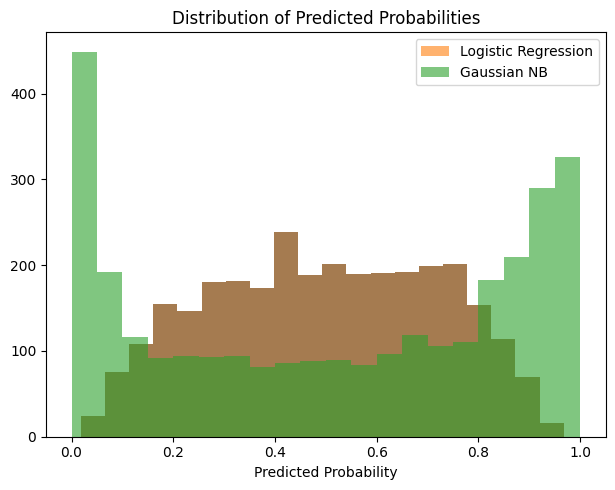

In [20]:
fig = plt.figure(figsize=(12,5))



ax2 = plt.subplot(122)
ax2.hist(
    est_lr.predict_proba(X_test)[:,1],
    bins=20,
)
ax2.hist(
    est_lr.predict_proba(X_test)[:,1],
    bins=20,
    alpha=0.6,
    label="Logistic Regression"
)

ax2.hist(
    est_nb.predict_proba(X_test)[:,1],
    bins=20,
    alpha=0.6,
    label="Gaussian NB"
)

ax2.set_title("Distribution of Predicted Probabilities")
ax2.set_xlabel("Predicted Probability")
ax2.legend()

plt.tight_layout()
plt.show()

## 1.Platt scaling

In [29]:
from sklearn.datasets import make_classification
## Step 1: create a dataset
X,y=make_classification(
    n_features=20,
    n_samples=10000,
    n_informative=10,
    n_redundant=5,
    random_state=42
)

from sklearn.model_selection import train_test_split
## Step 2: Split into train,test and validation split
X_train,X_tmp,y_train,y_tmp=train_test_split(X,y,test_size=0.4,stratify=y,random_state=42)
X_val,X_test,y_val,y_test=train_test_split(X_tmp,y_tmp,test_size=0.5,stratify=y_tmp,random_state=42)

from sklearn.naive_bayes import GaussianNB
## Step 3: Train Naive Bayes
nb=GaussianNB()
nb.fit(X_train,y_train)

## Step 4: Predict validation probabilites
val_probs=nb.predict_proba(X_val)[:,1]


from sklearn.linear_model import LogisticRegression
## Step 5: Train Platt Scaling
platt=LogisticRegression()
platt.fit(
    val_probs.reshape(-1,1),
    y_val
)


## Step 6: Predict Raw Test Probabilites
test_probs=nb.predict_proba(X_test)[:,1]


## Step 7: Apply platt scaling
calibrated_probs=platt.predict_proba(test_probs.reshape(-1,1))[:,1]


## Step 8: Compare performance 
from sklearn.metrics import roc_auc_score,brier_score_loss
print("Raw ROC-AUC")
print(roc_auc_score(y_test,test_probs))


print("Calibrated ROC-AUC")
print(roc_auc_score(y_test,calibrated_probs))



print("Raw Brier score")
print(brier_score_loss(y_test,test_probs))


print("Calibrated Brier score")
print(brier_score_loss(y_test,calibrated_probs))

Raw ROC-AUC
0.885064885064885
Calibrated ROC-AUC
0.885064885064885
Raw Brier score
0.14636405540540934
Calibrated Brier score
0.14253625676634532


## CalibratedClassifierCV

CalibratedClassifierCV is scikit-learn's built-in way to calibrate a classifier. It automates the calibration process, so you don't have to manually split the data and fit a logistic regression or isotonic regression yourself


***method='sigmoid' -> Platt Scaling***

***method='isotonic' -> Isotonic Regression***

***method= 'temperature'***

In [ ]:
# ============================================================
# Step 1 : Import Libraries
# ============================================================

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    log_loss
)

# ============================================================
# Step 2 : Create Dataset
# ============================================================

X, y = make_classification(
    n_samples=10000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    random_state=42
)

# ============================================================
# Step 3 : Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ============================================================
# Step 4 : Create Base Model
# ============================================================

base_est = GaussianNB()

# ============================================================
# Step 5 : Wrap Base Model with Calibrator
# method="sigmoid"  -> Platt Scaling
# method="isotonic" -> Isotonic Regression
# cv=5 means 5-fold cross validation
# ============================================================


calibrated_model=CalibratedClassifierCV(base_est,method='sigmoid',cv=5)

# ============================================================
# Step 6 : Train
# ============================================================


calibrated_model.fit(X_train,y_train)

# ============================================================
# Step 7 : Predict Probabilities
# ============================================================

calibrated_probs=calibrated_model.predict_proba(X_test)[:,1]

# ============================================================
# Step 8 : Evaluation
# ============================================================

print("ROC-AUC")
print(roc_auc_score(y_test, calibrated_probs))

print()

print("Brier Score")
print(brier_score_loss(y_test, calibrated_probs))

print()

print("Log Loss")
print(log_loss(y_test, calibrated_probs))

ROC-AUC
0.8903008903008903

Brier Score
0.1366048832846349

Log Loss
0.4310105371987357


In [ ]:
# cv="prefit" was an older mode of CalibratedClassifierCV that meant:
# "Don't train my base model. I have already trained it. Just calibrate it."
# It is useful when you have already trained a model and 
# you have a separate calibration (validation) dataset.
# Note: In recent versions of scikit-learn (1.6+), cv="prefit" is deprecated. 
# The recommended replacement is using a fitted estimator via FrozenEstimator. 
# However, you'll still encounter cv="prefit" in many tutorials and older codebases.


from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

# The Random Forest is finished.You do not want to train it again.
# You only want calibration. Then, in older scikit-learn versions, you could write:

calibrator = CalibratedClassifierCV(
    estimator=rf,
    method="sigmoid",
    cv="prefit"
)

calibrator.fit(X_val, y_val)
## Don't retrain the random forest


# Already trained Random Forest
# ↓
# Predict probabilities on X_val
# ↓
# Train Platt Scaling

## Isotonic Regression

In [ ]:
from sklearn.datasets import make_classification

# =====================================================
# Step 1 : Create Dataset
# =====================================================

X, y = make_classification(
    n_samples=10000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    random_state=42
)

# =====================================================
# Step 2 : Train / Validation / Test Split
# =====================================================
from sklearn.model_selection import train_test_split

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X,
    y,
    test_size=0.4,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp,
    y_tmp,
    test_size=0.5,
    stratify=y_tmp,
    random_state=42
)

# =====================================================
# Step 3 : Train Base Model
# =====================================================

from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

# =====================================================
# Step 4 : Predict Validation Probabilities
# =====================================================

val_probs=nb.predict_proba(X_val)[:,1]

# =====================================================
# Step 5 : Train Isotonic Regression
# =====================================================

from sklearn.calibration import IsotonicRegression ## it is an algo just like linear regression or anything
## learns a monotonic function

iso=IsotonicRegression(y_min=0.0,y_max=1.0,out_of_bounds='clip')

iso.fit(val_probs.reshape(-1,1),y_val)


# =====================================================
# Step 6 : Predict Raw Test Probabilities
# =====================================================

test_probs=nb.predict_proba(X_test)[:,1]

# =====================================================
# Step 7 : Apply Isotonic Regression
# =====================================================

calibrated_probs=iso.predict(test_probs.reshape(-1,1))


from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    log_loss
)

print("Raw ROC-AUC")
print(roc_auc_score(y_test, test_probs))

print()

print("Calibrated ROC-AUC")
print(roc_auc_score(y_test, calibrated_probs))

print()

print("Raw Brier Score")
print(brier_score_loss(y_test, test_probs))

print()

print("Calibrated Brier Score")
print(brier_score_loss(y_test, calibrated_probs))

print()

print("Raw Log Loss")
print(log_loss(y_test, test_probs))

print()

print("Calibrated Log Loss")
print(log_loss(y_test, calibrated_probs))

Raw ROC-AUC
0.885064885064885

Calibrated ROC-AUC
0.8845368845368844

Raw Brier Score
0.14636405540540934

Calibrated Brier Score
0.13718662714308782

Raw Log Loss
0.4761469962832134

Calibrated Log Loss
0.4211512478715372


## CalibratedClassifierCV

In [50]:
## Just add method='isotonic' that's it 

# ============================================================
# Step 1 : Import Libraries
# ============================================================

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    log_loss
)

# ============================================================
# Step 2 : Create Dataset
# ============================================================

X, y = make_classification(
    n_samples=10000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    random_state=42
)

# ============================================================
# Step 3 : Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ============================================================
# Step 4 : Create Base Model
# ============================================================

base_est = GaussianNB()

# ============================================================
# Step 5 : Wrap Base Model with Calibrator
# method="sigmoid"  -> Platt Scaling
# method="isotonic" -> Isotonic Regression
# cv=5 means 5-fold cross validation
# ============================================================


calibrated_model=CalibratedClassifierCV(base_est,method='isotonic',cv=5)

# ============================================================
# Step 6 : Train
# ============================================================


calibrated_model.fit(X_train,y_train)

# ============================================================
# Step 7 : Predict Probabilities
# ============================================================

calibrated_probs=calibrated_model.predict_proba(X_test)[:,1]

# ============================================================
# Step 8 : Evaluation
# ============================================================

print("ROC-AUC")
print(roc_auc_score(y_test, calibrated_probs))

print()

print("Brier Score")
print(brier_score_loss(y_test, calibrated_probs))

print()

print("Log Loss")
print(log_loss(y_test, calibrated_probs))

ROC-AUC
0.8903218903218904

Brier Score
0.13358853361403528

Log Loss
0.43069142879645983
